# Alliance × Dynamics Analysis

This notebook extends the existing analysis stack by testing how alliance scores relate to coupling and regime dynamics, using dyad-clustered mixed models and the same artifact/config conventions used in the project notebooks.

## Load

In [1]:
from __future__ import annotations

import importlib.util
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

from scipy.stats import entropy, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['svg.fonttype'] = 'none'
sns.set_style('whitegrid')

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
cfg = yaml.safe_load((project_root / 'configs' / 'analysis.yaml').read_text())

artifacts_dir = project_root / cfg['analysis']['out_dir']
hmm_dir = project_root / cfg['analysis']['hmm_out_dir']
processed_dir = project_root / cfg['data']['processed_dir']
alliance_csv = project_root / 'alliance.csv'

analysis_dir = artifacts_dir / 'alliance_dynamics'
figure_dir = analysis_dir / 'notebook_figures'
table_dir = analysis_dir / 'notebook_tables'
figure_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)

print('Project root:', project_root)
print('Artifacts:', artifacts_dir)
print('Figures ->', figure_dir)
print('Tables  ->', table_dir)

Project root: /Users/cartersale/Research/Projects/Affect-Dynamics
Artifacts: /Users/cartersale/Research/Projects/Affect-Dynamics/artifacts
Figures -> /Users/cartersale/Research/Projects/Affect-Dynamics/artifacts/alliance_dynamics/notebook_figures
Tables  -> /Users/cartersale/Research/Projects/Affect-Dynamics/artifacts/alliance_dynamics/notebook_tables


In [2]:
def _load_script_module(script_path: Path, module_name: str):
    spec = importlib.util.spec_from_file_location(module_name, script_path)
    mod = importlib.util.module_from_spec(spec)
    assert spec.loader is not None
    spec.loader.exec_module(mod)
    return mod

def normalize_dyad_id(x) -> str:
    s = str(x).strip()
    s = s.split('.')[0]
    digits = ''.join(ch for ch in s if ch.isdigit())
    if digits:
        return f'{int(digits):03d}'
    return s.upper()

def normalize_session_code_to_id(code: str) -> str | None:
    if pd.isna(code):
        return None
    s = str(code).strip().upper().replace(' ', '')
    if len(s) < 2:
        return None
    letter = s[-1]
    if letter not in {'A', 'B'}:
        return None
    num = ''.join(ch for ch in s[:-1] if ch.isdigit())
    if not num:
        return None
    return f'{int(num):03d}_{letter}'

def compute_regime_stats(path: np.ndarray, n_states: int):
    path = np.asarray(path, dtype=np.int64)
    if path.size < 2:
        return {
            'r_switch': np.nan,
            'mean_dwell': np.nan,
            'cv_dwell': np.nan,
            'h_trans': np.nan,
            'h_occ': np.nan,
        }

    n_switches = np.sum(path[:-1] != path[1:])
    r_switch = n_switches / (len(path) - 1)

    loc_run_start = np.empty(len(path), dtype=bool)
    loc_run_start[0] = True
    np.not_equal(path[:-1], path[1:], out=loc_run_start[1:])
    run_starts = np.nonzero(loc_run_start)[0]
    run_lengths = np.diff(np.append(run_starts, len(path))).astype(float)

    mean_dwell = float(np.mean(run_lengths))
    cv_dwell = float(np.std(run_lengths) / mean_dwell) if mean_dwell > 0 else np.nan

    counts = np.bincount(path, minlength=n_states).astype(float)
    occ = counts / max(counts.sum(), 1.0)
    h_occ = float(entropy(occ, base=2))

    trans = np.zeros((n_states, n_states), dtype=float)
    for t in range(len(path) - 1):
        trans[path[t], path[t + 1]] += 1.0

    row_sums = trans.sum(axis=1, keepdims=True)
    probs = np.divide(trans, row_sums, out=np.zeros_like(trans), where=row_sums != 0)
    row_ent = np.array([entropy(row, base=2) if s > 0 else 0.0 for row, s in zip(probs, row_sums[:, 0])])
    h_trans = float(np.sum(occ * row_ent))

    return {
        'r_switch': float(r_switch),
        'mean_dwell': mean_dwell,
        'cv_dwell': cv_dwell,
        'h_trans': h_trans,
        'h_occ': h_occ,
    }

def zscore(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors='coerce')
    mu, sd = s.mean(), s.std(ddof=0)
    if pd.isna(sd) or sd == 0:
        return pd.Series(np.nan, index=series.index)
    return (s - mu) / sd

def _fit_mixedlm(data: pd.DataFrame, outcome: str, predictors: list[str], group_col: str = 'dyad_id'):
    cols = [outcome, group_col] + predictors
    d = data[cols].dropna().copy()
    if d.empty or d[group_col].nunique() < 2:
        return None, d, {}, {}

    d[outcome] = pd.to_numeric(d[outcome], errors='coerce')
    for p in predictors:
        d[p] = pd.to_numeric(d[p], errors='coerce')
    d = d[[outcome, group_col] + predictors].dropna().copy()
    if d.empty or d[group_col].nunique() < 2:
        return None, d, {}, {}

    zmap = {}
    zstats = {}
    for idx, p in enumerate(predictors):
        s = pd.to_numeric(d[p], errors='coerce')
        sd = s.std(ddof=0)
        if pd.isna(sd) or sd == 0:
            continue
        mu = s.mean()
        zname = f'z__x{idx}'
        d[zname] = (s - mu) / sd
        zmap[p] = zname
        zstats[p] = {'mean': float(mu), 'sd': float(sd)}

    zpreds = [zmap[p] for p in predictors]
    if len(zpreds) == 0:
        return None, d, zmap, zstats
    d = d[[outcome, group_col] + zpreds].dropna().copy()
    if d.empty or d[group_col].nunique() < 2:
        return None, d, zmap, zstats

    outcome_col = '__outcome__'
    d[outcome_col] = d[outcome]
    formula = f"{outcome_col} ~ {' + '.join(zpreds)}"
    model = smf.mixedlm(formula=formula, data=d, groups=d[group_col])

    fit = None
    for method in ['lbfgs', 'powell', 'cg']:
        try:
            fit = model.fit(reml=False, method=method, maxiter=400, disp=False)
            break
        except Exception:
            fit = None

    return fit, d, zmap, zstats

def fixed_effect_table(fit, d: pd.DataFrame, zmap: dict[str, str]):
    if fit is None:
        return pd.DataFrame()

    conf = fit.conf_int()
    inv_zmap = {v: k for k, v in zmap.items()}
    rows = []
    for term, coef in fit.fe_params.items():
        se = fit.bse_fe.get(term, np.nan)
        z = coef / se if pd.notna(se) and se != 0 else np.nan
        p = fit.pvalues.get(term, np.nan)
        ci_low = conf.loc[term, 0] if term in conf.index else np.nan
        ci_high = conf.loc[term, 1] if term in conf.index else np.nan

        raw_name = inv_zmap.get(term, term)
        effect_per_sd = coef if term in inv_zmap else np.nan

        rows.append({
            'term': term,
            'raw_term': raw_name,
            'coef': coef,
            'se': se,
            'z_or_t': z,
            'p_value': p,
            'ci_low': ci_low,
            'ci_high': ci_high,
            'effect_per_sd': effect_per_sd,
            'n_sessions': len(d),
            'n_dyads': d['dyad_id'].nunique(),
        })

    return pd.DataFrame(rows)

def primary_and_subscales(df: pd.DataFrame):
    wai_primary = [c for c in ['Difference (Cl-Ther)'] if c in df.columns]
    rri_primary = [c for c in ['RRI Total'] if c in df.columns]
    primary = wai_primary + rri_primary

    wai_sub = [c for c in ['WAIT Task', 'WAIT Bond', 'WAIT Goal', 'WAIC Task', 'WAIC Bond', 'WAIC Goal'] if c in df.columns]
    rri_sub = [c for c in ['RRI  Genuine', 'RRI Genuine', 'RRI Realism'] if c in df.columns]

    # Remove duplicates while preserving order
    seen = set()
    sub = []
    for c in wai_sub + rri_sub:
        if c not in seen:
            sub.append(c)
            seen.add(c)

    sub = [c for c in sub if c not in primary]
    return primary, sub

def load_standard_session_level_df(project_root: Path) -> pd.DataFrame:
    # Reuse existing session loader from repository script
    catrqa_script = project_root / 'scripts' / '04_catRQA.py'
    mod = _load_script_module(catrqa_script, 'catrqa_loader')
    sessions, mf = mod.load_sessions(processed_dir)

    session_map = {str(s.session_id): s for s in sessions}

    coupling = pd.read_csv(artifacts_dir / 'coupling_results.csv')
    directionality = pd.read_csv(artifacts_dir / 'directionality_results.csv')
    decoded = pd.read_csv(hmm_dir / 'decoded_sessions.csv')
    alliance = pd.read_csv(alliance_csv)

    # Normalize identifiers
    coupling['session_id'] = coupling['session_id'].astype(str).str.upper()
    directionality['session_id'] = directionality['session_id'].astype(str).str.upper()
    decoded['session_id'] = decoded['session_id'].astype(str).str.upper()

    for df_ in [coupling, directionality, decoded]:
        df_['dyad_id'] = df_['dyad_id'].apply(normalize_dyad_id)

    alliance = alliance.copy()
    alliance['session_id'] = alliance['Session Code'].map(normalize_session_code_to_id)
    alliance = alliance[alliance['session_id'].notna()].copy()
    alliance['dyad_id'] = alliance['session_id'].str.split('_').str[0].apply(normalize_dyad_id)

    merged = coupling.merge(directionality, on=['fold', 'session_id', 'dyad_id'], how='left')
    merged = merged.merge(decoded, on=['session_id', 'dyad_id'], how='left')

    # Coupling gain aliases
    merged['delta_ll'] = merged['gain_per_trans']
    if 'dT_per_trans' in merged.columns:
        merged['delta_t'] = merged['dT_per_trans']
    if 'dC_per_trans' in merged.columns:
        merged['delta_c'] = merged['dC_per_trans']

    # Occupancy aliases p_k from occ_0..occ_{K-1}
    occ_cols = sorted([c for c in merged.columns if c.startswith('occ_')], key=lambda c: int(c.split('_')[1]))
    for idx, c in enumerate(occ_cols, start=1):
        merged[f'p_{idx}'] = merged[c]

    # Regime dynamics from saved Viterbi paths
    n_states = len(occ_cols) if occ_cols else 8
    stats_rows = []
    for sid in merged['session_id'].unique():
        path_file = hmm_dir / f'{sid}_viterbi.npy'
        if not path_file.exists():
            stats_rows.append({'session_id': sid, 'r_switch': np.nan, 'mean_dwell': np.nan, 'cv_dwell': np.nan, 'h_trans': np.nan, 'h_occ': np.nan})
            continue
        path = np.load(path_file)
        st = compute_regime_stats(path=path, n_states=n_states)
        st['session_id'] = sid
        stats_rows.append(st)

    stats_df = pd.DataFrame(stats_rows)
    merged = merged.merge(stats_df, on='session_id', how='left')

    # PCA (PC1, PC2) from same feature family used in regime notebook
    pca_cols = ['r_switch', 'mean_dwell', 'cv_dwell', 'h_trans', 'h_occ']
    pca_data = merged[pca_cols].copy()
    valid = pca_data.notna().all(axis=1)
    merged['pc1'] = np.nan
    merged['pc2'] = np.nan
    if valid.sum() >= 3:
        X = StandardScaler().fit_transform(pca_data.loc[valid])
        pcs = PCA(n_components=2, random_state=SEED).fit_transform(X)
        merged.loc[valid, 'pc1'] = pcs[:, 0]
        merged.loc[valid, 'pc2'] = pcs[:, 1]

    # Alliance merge (keep original alliance column names)
    alliance_keep = [c for c in alliance.columns if c not in ['Gender', 'Projected 4th Sess.', 'A or B (1= A)', 'Coded? (1= Yes)']]
    alliance_sub = alliance[['session_id', 'dyad_id'] + [c for c in alliance_keep if c not in ['session_id', 'dyad_id']]].copy()
    merged = merged.merge(alliance_sub, on=['session_id', 'dyad_id'], how='left')

    # Recompute alliance difference directly (Client - Therapist) for consistency
    if 'WAIC Total' in merged.columns and 'WAIT Total' in merged.columns:
        wai_client = pd.to_numeric(merged['WAIC Total'], errors='coerce')
        wai_ther = pd.to_numeric(merged['WAIT Total'], errors='coerce')
        merged['Difference (Cl-Ther)'] = wai_client - wai_ther

    merged['n_steps'] = pd.to_numeric(merged.get('n_steps', np.nan), errors='coerce')
    merged['n_transitions'] = pd.to_numeric(merged.get('n_transitions', np.nan), errors='coerce')

    return merged

analysis_df = load_standard_session_level_df(project_root)
print('Session-level table shape:', analysis_df.shape)
display(analysis_df.head())

Session-level table shape: (123, 118)


,fold,session_id,dyad_id,n_transitions,ll0_total,ll1_total,ll0_per_trans,ll1_per_trans,gain_per_trans,nT,...,RevWAIC4,RevWAIC10,WAIC Task,WAIC Bond,WAIC Goal,WAIT Total,WAIC Total,Difference (Cl-Ther),Unnamed: 77,Unnamed: 78
0,0,007_A,007,5398,-1987.128886,-1981.706934,-0.368123,-0.367119,0.001004,2699,...,7.0,4.0,17.0,11.0,20.0,54.0,48.0,-6.0,NaN,NaN
1,0,007_B,007,4306,-1620.139383,-1615.810658,-0.376252,-0.375246,0.001005,2153,...,7.0,7.0,24.0,18.0,26.0,59.0,68.0,9.0,NaN,NaN
2,0,022_A,022,5398,-2802.814775,-2808.025940,-0.519232,-0.520197,-0.000965,2699,...,7.0,6.0,23.0,27.0,26.0,62.0,76.0,14.0,NaN,NaN
3,0,022_B,022,5398,-3146.580002,-3141.248655,-0.582916,-0.581928,0.000988,2699,...,7.0,6.0,26.0,25.0,26.0,66.0,77.0,11.0,NaN,NaN
4,0,025_A,025,5398,-2090.868736,-2078.701997,-0.387341,-0.385087,0.002254,2699,...,1.0,7.0,28.0,28.0,22.0,74.0,78.0,4.0,NaN,NaN


## QC

In [3]:
primary_alliance, exploratory_subscales = primary_and_subscales(analysis_df)

print('N rows (sessions):', len(analysis_df))
print('N dyads:', analysis_df['dyad_id'].nunique())
print('Primary alliance columns:', primary_alliance)
print('Exploratory subscales:', exploratory_subscales)

required_cols = ['delta_ll', 'pc1', 'pc2', 'r_switch', 'mean_dwell', 'cv_dwell', 'h_trans', 'h_occ']
present_required = [c for c in required_cols if c in analysis_df.columns]
missing_required = [c for c in required_cols if c not in analysis_df.columns]
print('Present dynamics/coupling columns:', present_required)
print('Missing dynamics/coupling columns:', missing_required)

p_cols = sorted([c for c in analysis_df.columns if c.startswith('p_')], key=lambda c: int(c.split('_')[1]))
print('Occupancy columns:', p_cols[:5], '... total =', len(p_cols))

N rows (sessions): 123
N dyads: 93
Primary alliance columns: ['Difference (Cl-Ther)', 'RRI Total']
Exploratory subscales: ['WAIT Task', 'WAIT Bond', 'WAIT Goal', 'WAIC Task', 'WAIC Bond', 'WAIC Goal', 'RRI  Genuine', 'RRI Realism']
Present dynamics/coupling columns: ['delta_ll', 'pc1', 'pc2', 'r_switch', 'mean_dwell', 'cv_dwell', 'h_trans', 'h_occ']
Missing dynamics/coupling columns: []
Occupancy columns: ['p_1', 'p_2', 'p_3', 'p_4', 'p_5'] ... total = 8


## Models

In [4]:
def run_alliance_models(df: pd.DataFrame, outcomes: list[str], alliance_cols: list[str], covariates: list[str], block_name: str):
    all_rows = []
    model_meta = []

    for outcome in outcomes:
        if outcome not in df.columns:
            continue

        for alliance_col in alliance_cols:
            preds = [alliance_col] + [c for c in covariates if c in df.columns]
            fit, d, zmap, zstats = _fit_mixedlm(df, outcome=outcome, predictors=preds, group_col='dyad_id')
            tab = fixed_effect_table(fit, d, zmap=zmap)
            if tab.empty:
                continue

            tab['model_block'] = block_name
            tab['outcome'] = outcome
            tab['alliance_predictor'] = alliance_col
            used_predictors = list(zmap.keys())
            tab['covariates'] = ', '.join([c for c in used_predictors if c != alliance_col])
            tab['used_predictors'] = ', '.join(used_predictors)

            all_rows.append(tab)
            model_meta.append({'block': block_name, 'outcome': outcome, 'alliance': alliance_col, 'n': len(d), 'n_dyads': d['dyad_id'].nunique()})

    out = pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()
    meta = pd.DataFrame(model_meta)
    return out, meta

def apply_fdr_for_exploratory(model_table: pd.DataFrame, exploratory_cols: list[str], label: str):
    if model_table.empty:
        return model_table

    t = model_table.copy()
    t['is_exploratory'] = t['alliance_predictor'].isin(exploratory_cols) & (t['term'].str.startswith('z__'))

    pvals = t.loc[t['is_exploratory'], 'p_value']
    if len(pvals) > 0:
        reject, qvals, _, _ = multipletests(pvals.values, alpha=0.05, method='fdr_bh')
        t.loc[t['is_exploratory'], f'q_value_{label}'] = qvals
        t.loc[t['is_exploratory'], f'reject_fdr_{label}'] = reject

    return t

def fit_random_slope_model(df: pd.DataFrame, outcome: str, alliance_col: str, covariates: list[str], group_col: str = 'dyad_id'):
    cols = [outcome, alliance_col, group_col] + [c for c in covariates if c in df.columns]
    d = df[cols].copy()
    d[outcome] = pd.to_numeric(d[outcome], errors='coerce')
    d[alliance_col] = pd.to_numeric(d[alliance_col], errors='coerce')
    for c in covariates:
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors='coerce')
    d = d.dropna().copy()
    if d.empty or d[group_col].nunique() < 2:
        return None, d

    a_sd = d[alliance_col].std(ddof=0)
    if pd.isna(a_sd) or a_sd == 0:
        return None, d

    d['__y'] = d[outcome]
    d['z_alliance'] = (d[alliance_col] - d[alliance_col].mean()) / a_sd

    z_covars = []
    for idx, c in enumerate([c for c in covariates if c in d.columns]):
        sd = d[c].std(ddof=0)
        if pd.isna(sd) or sd == 0:
            continue
        zname = f'z_cov_{idx}'
        d[zname] = (d[c] - d[c].mean()) / sd
        z_covars.append(zname)

    rhs = ['z_alliance'] + z_covars
    formula = '__y ~ ' + ' + '.join(rhs)
    model = smf.mixedlm(formula=formula, data=d, groups=d[group_col], re_formula='~ z_alliance')

    fit = None
    for method in ['lbfgs', 'powell', 'cg']:
        try:
            fit = model.fit(reml=False, method=method, maxiter=500, disp=False)
            break
        except Exception:
            fit = None

    return fit, d

def per_dyad_slopes(df: pd.DataFrame, outcome: str, alliance_col: str, group_col: str = 'dyad_id', min_n: int = 3):
    cols = [outcome, alliance_col, group_col]
    d = df[cols].copy()
    d[outcome] = pd.to_numeric(d[outcome], errors='coerce')
    d[alliance_col] = pd.to_numeric(d[alliance_col], errors='coerce')
    d = d.dropna().copy()

    rows = []
    for dyad, g in d.groupby(group_col):
        if len(g) < min_n:
            continue
        x = g[alliance_col].to_numpy()
        y = g[outcome].to_numpy()
        if np.std(x) == 0 or np.std(y) == 0:
            continue
        slope, intercept = np.polyfit(x, y, 1)
        rows.append({
            'dyad_id': dyad,
            'outcome': outcome,
            'alliance_predictor': alliance_col,
            'n_sessions': len(g),
            'slope': float(slope),
            'intercept': float(intercept),
        })

    return pd.DataFrame(rows)

def fit_within_between(df: pd.DataFrame, outcome: str, alliance_col: str, covariates: list[str], group_col: str = 'dyad_id'):
    cols = [outcome, alliance_col, group_col] + [c for c in covariates if c in df.columns]
    d = df[cols].copy()
    d[outcome] = pd.to_numeric(d[outcome], errors='coerce')
    d[alliance_col] = pd.to_numeric(d[alliance_col], errors='coerce')
    for c in covariates:
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors='coerce')
    d = d.dropna().copy()
    if d.empty or d[group_col].nunique() < 2:
        return None, d

    d['alliance_mean_dyad'] = d.groupby(group_col)[alliance_col].transform('mean')
    d['alliance_within'] = d[alliance_col] - d['alliance_mean_dyad']
    d['alliance_between'] = d['alliance_mean_dyad']
    d['__y'] = d[outcome]

    for base_col, zname in [('alliance_within', 'z_alliance_within'), ('alliance_between', 'z_alliance_between')]:
        sd = d[base_col].std(ddof=0)
        if pd.isna(sd) or sd == 0:
            d[zname] = np.nan
        else:
            d[zname] = (d[base_col] - d[base_col].mean()) / sd

    cov_z = []
    for idx, c in enumerate([c for c in covariates if c in d.columns]):
        sd = d[c].std(ddof=0)
        if pd.isna(sd) or sd == 0:
            continue
        zname = f'z_cov_{idx}'
        d[zname] = (d[c] - d[c].mean()) / sd
        cov_z.append(zname)

    rhs = ['z_alliance_within', 'z_alliance_between'] + cov_z
    d = d[['__y', group_col] + rhs].dropna().copy()
    if d.empty or d[group_col].nunique() < 2:
        return None, d

    formula = '__y ~ ' + ' + '.join(rhs)
    model = smf.mixedlm(formula=formula, data=d, groups=d[group_col])

    fit = None
    for method in ['lbfgs', 'powell', 'cg']:
        try:
            fit = model.fit(reml=False, method=method, maxiter=500, disp=False)
            break
        except Exception:
            fit = None

    return fit, d

primary_alliance, exploratory_subscales = primary_and_subscales(analysis_df)

# (1) Alliance -> Coupling gains
coupling_outcomes = [c for c in ['delta_ll', 'delta_t', 'delta_c'] if c in analysis_df.columns]
covars_coupling = [c for c in ['n_transitions'] if c in analysis_df.columns]

m1_primary, m1_primary_meta = run_alliance_models(
    analysis_df,
    outcomes=coupling_outcomes,
    alliance_cols=primary_alliance,
    covariates=covars_coupling,
    block_name='alliance_to_coupling_primary'
)

m1_expl, m1_expl_meta = run_alliance_models(
    analysis_df,
    outcomes=coupling_outcomes,
    alliance_cols=exploratory_subscales,
    covariates=covars_coupling,
    block_name='alliance_to_coupling_exploratory'
)
m1_expl = apply_fdr_for_exploratory(m1_expl, exploratory_subscales, label='coupling')

# (A) Random-slope models
random_slope_rows = []
for outcome in coupling_outcomes:
    for alliance_col in primary_alliance:
        fit, d_rs = fit_random_slope_model(
            analysis_df,
            outcome=outcome,
            alliance_col=alliance_col,
            covariates=covars_coupling,
            group_col='dyad_id',
        )
        if fit is None:
            continue

        slope_var = np.nan
        if hasattr(fit, 'cov_re') and fit.cov_re is not None:
            if 'z_alliance' in fit.cov_re.index and 'z_alliance' in fit.cov_re.columns:
                slope_var = float(fit.cov_re.loc['z_alliance', 'z_alliance'])

        random_slope_rows.append({
            'outcome': outcome,
            'alliance_predictor': alliance_col,
            'n_sessions': len(d_rs),
            'n_dyads': d_rs['dyad_id'].nunique(),
            'fixed_z_alliance': float(fit.fe_params.get('z_alliance', np.nan)),
            'fixed_z_alliance_p': float(fit.pvalues.get('z_alliance', np.nan)),
            'random_slope_variance': slope_var,
            'converged': bool(getattr(fit, 'converged', False)),
            'loglike': float(getattr(fit, 'llf', np.nan)),
        })

random_slope_summary = pd.DataFrame(random_slope_rows)

# (B) Per-dyad OLS slopes
dyad_slope_frames = []
for outcome in coupling_outcomes:
    for alliance_col in primary_alliance:
        slopes = per_dyad_slopes(analysis_df, outcome=outcome, alliance_col=alliance_col, group_col='dyad_id', min_n=3)
        if not slopes.empty:
            dyad_slope_frames.append(slopes)

dyad_slopes = pd.concat(dyad_slope_frames, ignore_index=True) if dyad_slope_frames else pd.DataFrame()

if not dyad_slopes.empty:
    slope_plot_data = dyad_slopes[dyad_slopes['outcome'] == 'delta_ll'].copy()
    if slope_plot_data.empty:
        slope_plot_data = dyad_slopes.copy()

    g = sns.displot(
        data=slope_plot_data,
        x='slope',
        col='alliance_predictor',
        col_wrap=2,
        bins=18,
        kde=True,
        height=3.5,
        aspect=1.2,
    )
    for ax in g.axes.flatten():
        ax.axvline(0, color='black', ls='--', lw=1)
    g.fig.suptitle('Per-dyad OLS slope distributions', y=1.02)
    g.savefig(figure_dir / 'dyad_slope_distribution.svg', format='svg')
    plt.show()

# (C) Within vs between decomposition
wb_rows = []
for outcome in coupling_outcomes:
    for alliance_col in primary_alliance:
        fit_wb, d_wb = fit_within_between(
            analysis_df,
            outcome=outcome,
            alliance_col=alliance_col,
            covariates=covars_coupling,
            group_col='dyad_id',
        )
        if fit_wb is None:
            continue

        conf = fit_wb.conf_int()
        for term in ['z_alliance_within', 'z_alliance_between']:
            coef = fit_wb.fe_params.get(term, np.nan)
            se = fit_wb.bse_fe.get(term, np.nan)
            p = fit_wb.pvalues.get(term, np.nan)
            wb_rows.append({
                'outcome': outcome,
                'alliance_predictor': alliance_col,
                'term': term,
                'coef': coef,
                'se': se,
                'p_value': p,
                'ci_low': conf.loc[term, 0] if term in conf.index else np.nan,
                'ci_high': conf.loc[term, 1] if term in conf.index else np.nan,
                'n_sessions': len(d_wb),
                'n_dyads': d_wb['dyad_id'].nunique(),
            })

within_between_table = pd.DataFrame(wb_rows)

# (2) Alliance -> volatility / dwell
volatility_outcomes = [c for c in ['pc1', 'pc2', 'r_switch', 'mean_dwell', 'cv_dwell', 'h_trans', 'h_occ'] if c in analysis_df.columns]
covars_vol = [c for c in ['n_steps'] if c in analysis_df.columns]

m2_primary, m2_primary_meta = run_alliance_models(
    analysis_df,
    outcomes=volatility_outcomes,
    alliance_cols=primary_alliance,
    covariates=covars_vol,
    block_name='alliance_to_volatility_primary'
)

m2_expl, m2_expl_meta = run_alliance_models(
    analysis_df,
    outcomes=volatility_outcomes,
    alliance_cols=exploratory_subscales,
    covariates=covars_vol,
    block_name='alliance_to_volatility_exploratory'
)
m2_expl = apply_fdr_for_exploratory(m2_expl, exploratory_subscales, label='volatility')

display(m1_primary.head(20))
display(random_slope_summary.head(20))
display(within_between_table.head(20))
display(m2_primary.head(20))
print('Model sets complete.')

,term,raw_term,coef,se,z_or_t,p_value,ci_low,ci_high,effect_per_sd,n_sessions,n_dyads,model_block,outcome,alliance_predictor,covariates,used_predictors
0,Intercept,Intercept,8.323344e-04,0.000277,2.999961,0.002700,0.000289,0.001376,NaN,113,87,alliance_to_coupling_primary,delta_ll,Difference (Cl-Ther),n_transitions,"Difference (Cl-Ther), n_transitions"
1,z__x0,Difference (Cl-Ther),-3.007300e-05,0.000260,-0.115711,0.907881,-0.000539,0.000479,-3.007300e-05,113,87,alliance_to_coupling_primary,delta_ll,Difference (Cl-Ther),n_transitions,"Difference (Cl-Ther), n_transitions"
2,z__x1,n_transitions,4.932105e-04,0.000247,1.998424,0.045671,0.000009,0.000977,4.932105e-04,113,87,alliance_to_coupling_primary,delta_ll,Difference (Cl-Ther),n_transitions,"Difference (Cl-Ther), n_transitions"
3,Intercept,Intercept,8.737010e-04,0.000284,3.072136,0.002125,0.000316,0.001431,NaN,111,86,alliance_to_coupling_primary,delta_ll,RRI Total,n_transitions,"RRI Total, n_transitions"
4,z__x0,RRI Total,2.846458e-05,0.000240,0.118358,0.905784,-0.000443,0.000500,2.846458e-05,111,86,alliance_to_coupling_primary,delta_ll,RRI Total,n_transitions,"RRI Total, n_transitions"
5,z__x1,n_transitions,5.850692e-04,0.000245,2.392250,0.016745,0.000106,0.001064,5.850692e-04,111,86,alliance_to_coupling_primary,delta_ll,RRI Total,n_transitions,"RRI Total, n_transitions"
6,Intercept,Intercept,1.070602e-03,0.000346,3.092732,0.001983,0.000392,0.001749,NaN,113,87,alliance_to_coupling_primary,delta_t,Difference (Cl-Ther),n_transitions,"Difference (Cl-Ther), n_transitions"
7,z__x0,Difference (Cl-Ther),-1.917272e-04,0.000325,-0.590492,0.554861,-0.000828,0.000445,-1.917272e-04,113,87,alliance_to_coupling_primary,delta_t,Difference (Cl-Ther),n_transitions,"Difference (Cl-Ther), n_transitions"
8,z__x1,n_transitions,7.656378e-04,0.000314,2.436688,0.014822,0.000150,0.001381,7.656378e-04,113,87,alliance_to_coupling_primary,delta_t,Difference (Cl-Ther),n_transitions,"Difference (Cl-Ther), n_transitions"
9,Intercept,Intercept,1.116220e-03,0.000350,3.191682,0.001414,0.000431,0.001802,NaN,111,86,alliance_to_coupling_primary,delta_t,RRI Total,n_transitions,"RRI Total, n_transitions"


,outcome,alliance_predictor,n_sessions,n_dyads,fixed_z_alliance,fixed_z_alliance_p,random_slope_variance,converged,loglike
0,delta_ll,Difference (Cl-Ther),113,87,-0.000030,0.909284,2.362282e-08,True,510.309836
1,delta_ll,RRI Total,111,86,0.000011,0.967313,4.342958e-07,True,503.410582
2,delta_t,Difference (Cl-Ther),113,87,-0.000213,0.519639,2.002031e-07,True,483.227962
3,delta_t,RRI Total,111,86,0.000003,0.993496,2.212009e-08,True,476.122004
4,delta_c,Difference (Cl-Ther),113,87,0.000098,0.707902,2.964546e-08,True,512.593928
5,delta_c,RRI Total,111,86,0.000044,0.870529,2.606031e-07,True,506.160154


,outcome,alliance_predictor,term,coef,se,p_value,ci_low,ci_high,n_sessions,n_dyads
0,delta_ll,Difference (Cl-Ther),z_alliance_within,0.000010,0.000187,0.956003,-0.000356,0.000377,113,87
1,delta_ll,Difference (Cl-Ther),z_alliance_between,-0.000036,0.000265,0.892261,-0.000554,0.000483,113,87
2,delta_ll,RRI Total,z_alliance_within,-0.000176,0.000159,0.267859,-0.000488,0.000135,111,86
3,delta_ll,RRI Total,z_alliance_between,0.000310,0.000272,0.254082,-0.000223,0.000843,111,86
4,delta_t,Difference (Cl-Ther),z_alliance_within,-0.000021,0.000260,0.937027,-0.000530,0.000489,113,87
5,delta_t,Difference (Cl-Ther),z_alliance_between,-0.000193,0.000328,0.555907,-0.000836,0.000450,113,87
6,delta_t,RRI Total,z_alliance_within,-0.000225,0.000240,0.348634,-0.000695,0.000245,111,86
7,delta_t,RRI Total,z_alliance_between,0.000232,0.000335,0.489602,-0.000425,0.000888,111,86
8,delta_c,Difference (Cl-Ther),z_alliance_within,0.000039,0.000153,0.797156,-0.000261,0.000340,113,87
9,delta_c,Difference (Cl-Ther),z_alliance_between,0.000117,0.000272,0.667640,-0.000417,0.000650,113,87


,term,raw_term,coef,se,z_or_t,p_value,ci_low,ci_high,effect_per_sd,n_sessions,n_dyads,model_block,outcome,alliance_predictor,covariates,used_predictors
0,Intercept,Intercept,-0.091788,0.152133,-0.603341,5.462816e-01,-0.389965,0.206388,NaN,113,87,alliance_to_volatility_primary,pc1,Difference (Cl-Ther),n_steps,"Difference (Cl-Ther), n_steps"
1,z__x0,Difference (Cl-Ther),0.149178,0.144560,1.031949,3.020961e-01,-0.134153,0.432510,0.149178,113,87,alliance_to_volatility_primary,pc1,Difference (Cl-Ther),n_steps,"Difference (Cl-Ther), n_steps"
2,z__x1,n_steps,0.314082,0.141732,2.216033,2.668927e-02,0.036293,0.591872,0.314082,113,87,alliance_to_volatility_primary,pc1,Difference (Cl-Ther),n_steps,"Difference (Cl-Ther), n_steps"
3,Intercept,Intercept,-0.084119,0.155153,-0.542170,5.877013e-01,-0.388214,0.219975,NaN,111,86,alliance_to_volatility_primary,pc1,RRI Total,n_steps,"RRI Total, n_steps"
4,z__x0,RRI Total,0.018336,0.139095,0.131827,8.951209e-01,-0.254284,0.290957,0.018336,111,86,alliance_to_volatility_primary,pc1,RRI Total,n_steps,"RRI Total, n_steps"
5,z__x1,n_steps,0.328930,0.144755,2.272324,2.306697e-02,0.045216,0.612644,0.328930,111,86,alliance_to_volatility_primary,pc1,RRI Total,n_steps,"RRI Total, n_steps"
6,Intercept,Intercept,-0.010081,0.126518,-0.079684,9.364884e-01,-0.258052,0.237889,NaN,113,87,alliance_to_volatility_primary,pc2,Difference (Cl-Ther),n_steps,"Difference (Cl-Ther), n_steps"
7,z__x0,Difference (Cl-Ther),-0.070885,0.116670,-0.607563,5.434774e-01,-0.299554,0.157785,-0.070885,113,87,alliance_to_volatility_primary,pc2,Difference (Cl-Ther),n_steps,"Difference (Cl-Ther), n_steps"
8,z__x1,n_steps,0.212921,0.112819,1.887279,5.912284e-02,-0.008200,0.434043,0.212921,113,87,alliance_to_volatility_primary,pc2,Difference (Cl-Ther),n_steps,"Difference (Cl-Ther), n_steps"
9,Intercept,Intercept,-0.024790,0.128439,-0.193010,8.469508e-01,-0.276525,0.226945,NaN,111,86,alliance_to_volatility_primary,pc2,RRI Total,n_steps,"RRI Total, n_steps"


Model sets complete.


In [5]:
# Cancellation diagnostic summary (compact)
def summarize_cancellation(random_slope_summary: pd.DataFrame, dyad_slopes: pd.DataFrame, within_between_table: pd.DataFrame):
    rows = []

    if dyad_slopes.empty:
        print('No dyad-level slopes available; cannot assess cancellation.')
        return pd.DataFrame()

    outcomes = sorted(dyad_slopes['outcome'].dropna().unique().tolist())
    alliances = sorted(dyad_slopes['alliance_predictor'].dropna().unique().tolist())

    for outcome in outcomes:
        for alliance in alliances:
            dsl = dyad_slopes[(dyad_slopes['outcome'] == outcome) & (dyad_slopes['alliance_predictor'] == alliance)].copy()
            if dsl.empty:
                continue

            slope_mean = float(dsl['slope'].mean())
            slope_median = float(dsl['slope'].median())
            slope_sd = float(dsl['slope'].std(ddof=0))
            pos_frac = float((dsl['slope'] > 0).mean())
            abs_median = float(dsl['slope'].abs().median())

            sym_centered = abs(slope_median) < 0.25 * max(slope_sd, 1e-12)
            mixed_signs = 0.30 <= pos_frac <= 0.70

            rs = random_slope_summary[(random_slope_summary['outcome'] == outcome) & (random_slope_summary['alliance_predictor'] == alliance)]
            if rs.empty:
                slope_var = np.nan
                fixed_p = np.nan
            else:
                slope_var = float(rs['random_slope_variance'].iloc[0])
                fixed_p = float(rs['fixed_z_alliance_p'].iloc[0])

            wb = within_between_table[(within_between_table['outcome'] == outcome) & (within_between_table['alliance_predictor'] == alliance)]
            p_within = float(wb.loc[wb['term'] == 'z_alliance_within', 'p_value'].iloc[0]) if ((wb['term'] == 'z_alliance_within').any()) else np.nan
            p_between = float(wb.loc[wb['term'] == 'z_alliance_between', 'p_value'].iloc[0]) if ((wb['term'] == 'z_alliance_between').any()) else np.nan

            cancellation_likely = bool(sym_centered and mixed_signs and (pd.notna(slope_var) and slope_var > 0) and (pd.isna(fixed_p) or fixed_p > 0.05))

            rows.append({
                'outcome': outcome,
                'alliance_predictor': alliance,
                'n_dyads_with_slope': int(len(dsl)),
                'slope_mean': slope_mean,
                'slope_median': slope_median,
                'slope_sd': slope_sd,
                'positive_slope_fraction': pos_frac,
                'random_slope_variance': slope_var,
                'fixed_effect_p': fixed_p,
                'within_p': p_within,
                'between_p': p_between,
                'cancellation_likely': cancellation_likely,
                'rule_flags': f'sym={sym_centered},mixed={mixed_signs},var>0={pd.notna(slope_var) and slope_var > 0},fixed_ns={pd.isna(fixed_p) or fixed_p > 0.05}',
            })

    out = pd.DataFrame(rows)
    if out.empty:
        print('No rows available for cancellation summary.')
        return out

    display_cols = [
        'outcome', 'alliance_predictor', 'n_dyads_with_slope',
        'slope_mean', 'slope_median', 'slope_sd', 'positive_slope_fraction',
        'random_slope_variance', 'fixed_effect_p', 'within_p', 'between_p',
        'cancellation_likely', 'rule_flags',
    ]
    display(out[display_cols].sort_values(['outcome', 'alliance_predictor']))
    return out

cancellation_summary = summarize_cancellation(
    random_slope_summary=random_slope_summary,
    dyad_slopes=dyad_slopes,
    within_between_table=within_between_table,
    )

No dyad-level slopes available; cannot assess cancellation.


In [6]:
# (C) Coefficient models: alliance_total ~ standardized dynamics + random intercept(dyad)
# p_k terms are excluded from primary models to avoid outcome-driven feature selection.

coef_models = []
coef_rows = []
base_predictors = [c for c in ['pc1','pc2'] if c in analysis_df.columns]

coef_targets = [c for c in ['Difference (Cl-Ther)', 'RRI Total'] if c in analysis_df.columns]
for target in coef_targets:
    predictors = base_predictors.copy()

    fit, d, zmap, zstats = _fit_mixedlm(analysis_df, outcome=target, predictors=predictors, group_col='dyad_id')
    tab = fixed_effect_table(fit, d, zmap=zmap)
    if tab.empty:
        continue

    tab['coef_target'] = target
    tab['selected_p_cols'] = ''
    coef_rows.append(tab)
    coef_models.append({'target': target, 'predictors': predictors, 'n': len(d), 'n_dyads': d['dyad_id'].nunique(), 'pk_strategy': 'excluded_in_primary'})

coef_table = pd.concat(coef_rows, ignore_index=True) if coef_rows else pd.DataFrame()
coef_meta = pd.DataFrame(coef_models)
display(coef_meta)
display(coef_table.head(20))

,target,predictors,n,n_dyads,pk_strategy
0,Difference (Cl-Ther),"[pc1, pc2]",113,87,excluded_in_primary
1,RRI Total,"[pc1, pc2]",111,86,excluded_in_primary


,term,raw_term,coef,se,z_or_t,p_value,ci_low,ci_high,effect_per_sd,n_sessions,n_dyads,coef_target,selected_p_cols
0,Intercept,Intercept,5.768493,1.603645,3.597114,0.000322,2.625407,8.911579,NaN,113,87,Difference (Cl-Ther),
1,z__x0,pc1,0.496720,1.132461,0.438620,0.660937,-1.722862,2.716302,0.496720,113,87,Difference (Cl-Ther),
2,z__x1,pc2,-0.655838,1.243089,-0.527587,0.597786,-3.092248,1.780572,-0.655838,113,87,Difference (Cl-Ther),
3,Intercept,Intercept,89.612613,1.896560,47.250074,0.000000,85.895423,93.329802,NaN,111,86,RRI Total,
4,z__x0,pc1,0.202487,1.908586,0.106092,0.915509,-3.538274,3.943247,0.202487,111,86,RRI Total,
5,z__x1,pc2,1.825267,1.900356,0.960487,0.336810,-1.899362,5.549896,1.825267,111,86,RRI Total,


## Plots

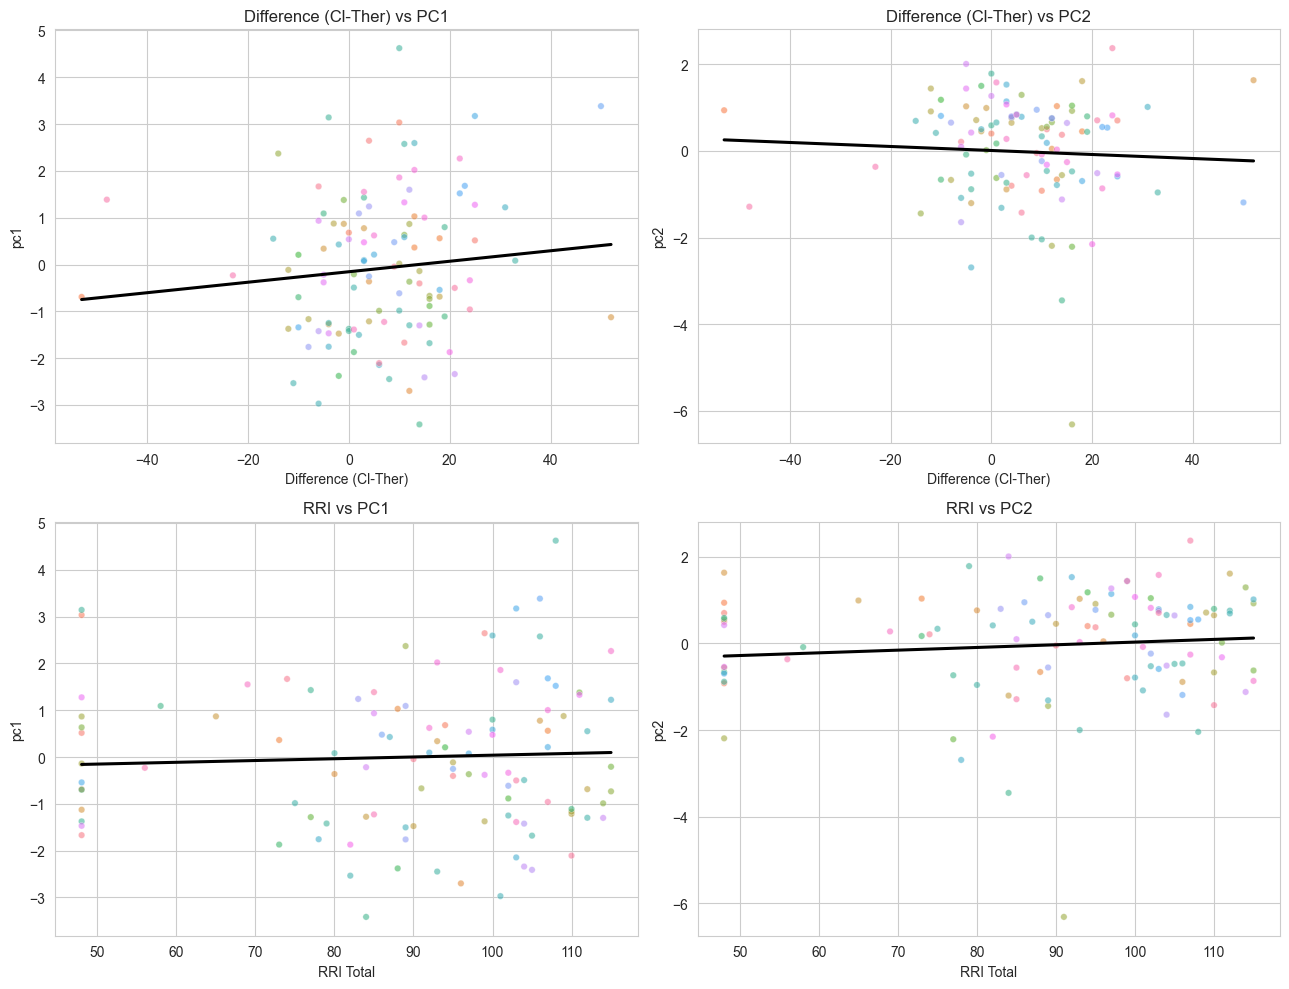

In [7]:
# A) Scatter panels (dyad clustering-aware fitted line from mixed model fixed effects)
wai_panel = 'Difference (Cl-Ther)' if 'Difference (Cl-Ther)' in analysis_df.columns else None
panel_specs = []
if wai_panel is not None:
    panel_specs.extend([
        (wai_panel, 'pc1', f'{wai_panel} vs PC1'),
        (wai_panel, 'pc2', f'{wai_panel} vs PC2'),
    ])
panel_specs.extend([
    ('RRI Total', 'pc1', 'RRI vs PC1'),
    ('RRI Total', 'pc2', 'RRI vs PC2'),
])
panel_specs = [s for s in panel_specs if s[0] in analysis_df.columns and s[1] in analysis_df.columns]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()

for i, (xcol, ycol, title) in enumerate(panel_specs):
    ax = axes[i]
    d = analysis_df[[xcol, ycol, 'dyad_id']].copy()
    d[xcol] = pd.to_numeric(d[xcol], errors='coerce')
    d[ycol] = pd.to_numeric(d[ycol], errors='coerce')
    d = d.dropna(subset=[xcol, ycol, 'dyad_id']).copy()
    if d.empty:
        ax.set_title(title)
        ax.text(0.5, 0.5, 'No numeric data', ha='center', va='center', transform=ax.transAxes)
        continue

    sns.scatterplot(data=d, x=xcol, y=ycol, hue='dyad_id', legend=False, s=22, alpha=0.55, ax=ax)

    fit, dm, zmap, zstats = _fit_mixedlm(d, outcome=ycol, predictors=[xcol], group_col='dyad_id')
    if fit is not None and not dm.empty and xcol in zmap and xcol in zstats:
        x_grid = np.linspace(d[xcol].min(), d[xcol].max(), 120)
        mu, sd = zstats[xcol]['mean'], zstats[xcol]['sd']
        if sd > 0:
            xz = (x_grid - mu) / sd
            b0 = fit.fe_params.get('Intercept', 0.0)
            b1 = fit.fe_params.get(zmap[xcol], np.nan)
            if pd.notna(b1):
                y_hat = b0 + b1 * xz
                ax.plot(x_grid, y_hat, color='black', lw=2.2)

    ax.set_title(title)

for j in range(len(panel_specs), 4):
    axes[j].axis('off')

fig.tight_layout()
fig.savefig(figure_dir / 'alliance_pc_scatter_mixed.svg', format='svg')
plt.show()

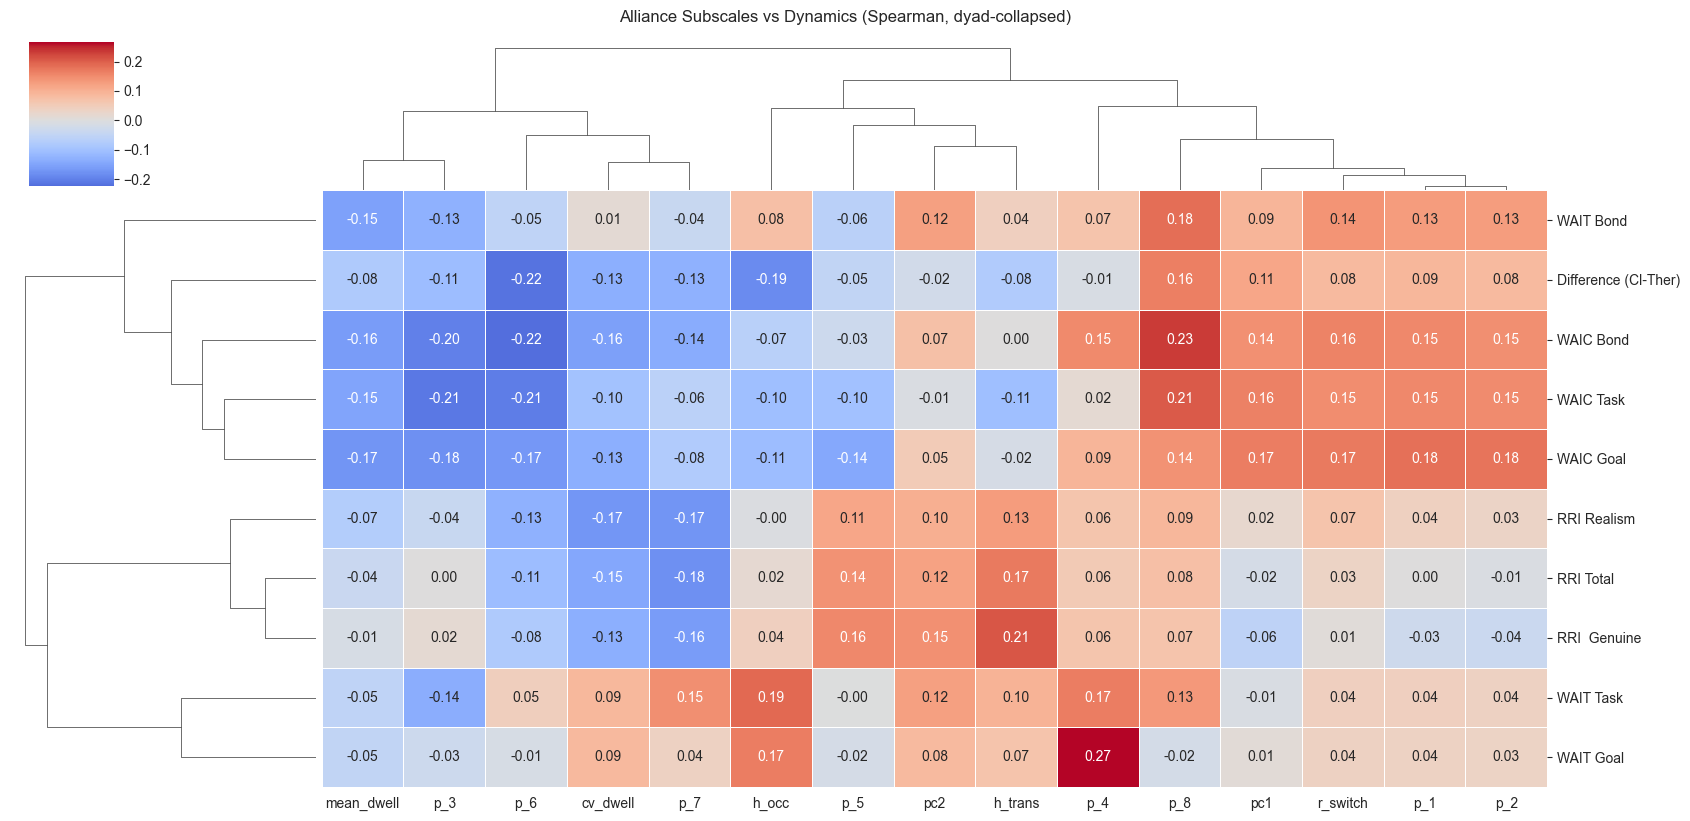

In [8]:
# B) Dyad-collapsed Spearman heatmap with hierarchical clustering
alliance_cols = [c for c in (primary_alliance + exploratory_subscales) if c in analysis_df.columns]
dyn_cols = [c for c in ['pc1', 'pc2', 'r_switch', 'mean_dwell', 'cv_dwell', 'h_trans', 'h_occ'] if c in analysis_df.columns] + p_cols

dyad_cols = ['dyad_id'] + alliance_cols + dyn_cols
dyad_df = analysis_df[dyad_cols].copy()
for c in alliance_cols + dyn_cols:
    dyad_df[c] = pd.to_numeric(dyad_df[c], errors='coerce')
dyad_df = dyad_df.groupby('dyad_id', as_index=False)[alliance_cols + dyn_cols].mean()

corr_cross = pd.DataFrame(index=alliance_cols, columns=dyn_cols, dtype=float)
pval_cross = pd.DataFrame(index=alliance_cols, columns=dyn_cols, dtype=float)

for a in alliance_cols:
    for dcol in dyn_cols:
        sub = dyad_df[[a, dcol]].dropna()
        if len(sub) < 8:
            corr_cross.loc[a, dcol] = np.nan
            pval_cross.loc[a, dcol] = np.nan
            continue
        rho, p = spearmanr(sub[a], sub[dcol])
        corr_cross.loc[a, dcol] = rho
        pval_cross.loc[a, dcol] = p

cg = sns.clustermap(
    corr_cross.astype(float),
    cmap='coolwarm', center=0,
    annot=True, fmt='.2f',
    linewidths=0.4,
    figsize=(17, 8),
)
cg.fig.suptitle('Alliance Subscales vs Dynamics (Spearman, dyad-collapsed)', y=1.02)
cg.savefig(figure_dir / 'alliance_dynamics_corr_clustermap.svg', format='svg')
plt.show()

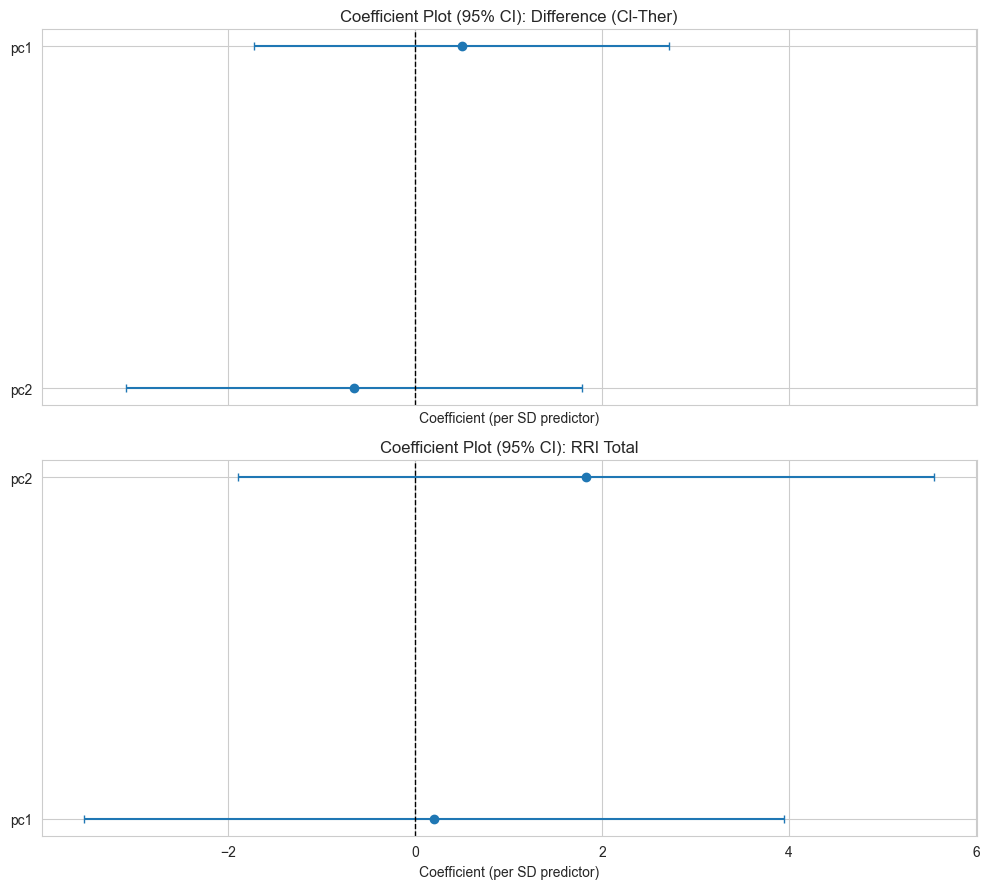

In [9]:
# C) Coefficient plot for multivariable mixed models
if not coef_table.empty:
    plot_df = coef_table.copy()
    plot_df = plot_df[plot_df['term'].str.startswith('z__')].copy()

    targets = plot_df['coef_target'].dropna().unique().tolist()
    nrows = len(targets)

    fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(10, 4.5 * max(nrows, 1)), sharex=True)
    if nrows == 1:
        axes = [axes]

    for ax, target in zip(axes, targets):
        d = plot_df[plot_df['coef_target'] == target].copy()
        d = d[d['term'] != 'Intercept'].sort_values('coef')
        y = np.arange(len(d))

        ax.errorbar(
            x=d['coef'],
            y=y,
            xerr=[d['coef'] - d['ci_low'], d['ci_high'] - d['coef']],
            fmt='o',
            color='tab:blue',
            ecolor='tab:blue',
            elinewidth=1.5,
            capsize=3,
        )
        ax.axvline(0, color='black', lw=1, ls='--')
        ax.set_yticks(y)
        ax.set_yticklabels(d['raw_term'])
        ax.set_title(f'Coefficient Plot (95% CI): {target}')
        ax.set_xlabel('Coefficient (per SD predictor)')

    fig.tight_layout()
    fig.savefig(figure_dir / 'alliance_total_multivariable_coefplot.svg', format='svg')
    plt.show()
else:
    print('No coefficient models available for plotting.')

## Save

In [10]:
# Save model and correlation outputs
analysis_df.to_csv(table_dir / 'session_level_alliance_dynamics_table.csv', index=False)

m1_primary.to_csv(table_dir / 'models_alliance_to_coupling_primary.csv', index=False)
m1_expl.to_csv(table_dir / 'models_alliance_to_coupling_exploratory_fdr.csv', index=False)
m2_primary.to_csv(table_dir / 'models_alliance_to_volatility_primary.csv', index=False)
m2_expl.to_csv(table_dir / 'models_alliance_to_volatility_exploratory_fdr.csv', index=False)

random_slope_summary.to_csv(table_dir / 'models_alliance_to_coupling_random_slope_summary.csv', index=False)
within_between_table.to_csv(table_dir / 'models_alliance_to_coupling_within_between.csv', index=False)
dyad_slopes.to_csv(table_dir / 'models_alliance_to_coupling_dyad_ols_slopes.csv', index=False)

pd.concat([m1_primary_meta, m1_expl_meta, m2_primary_meta, m2_expl_meta], ignore_index=True).to_csv(
    table_dir / 'model_run_metadata.csv', index=False
)

corr_cross.to_csv(table_dir / 'alliance_dynamics_spearman_matrix.csv')
pval_cross.to_csv(table_dir / 'alliance_dynamics_spearman_pvalues.csv')

if not coef_table.empty:
    coef_table.to_csv(table_dir / 'models_alliance_total_multivariable_coefficients.csv', index=False)
if not coef_meta.empty:
    coef_meta.to_csv(table_dir / 'models_alliance_total_multivariable_metadata.csv', index=False)

print('Saved tables to:', table_dir)
print('Saved figures to:', figure_dir)

Saved tables to: /Users/cartersale/Research/Projects/Affect-Dynamics/artifacts/alliance_dynamics/notebook_tables
Saved figures to: /Users/cartersale/Research/Projects/Affect-Dynamics/artifacts/alliance_dynamics/notebook_figures
